In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter


In [5]:
# 参数
CSV_PATH = 'event74_hits.csv'
EVENT = 74
LAYER = 23


In [6]:
# choose layer
df = pd.read_csv("event74_hits.csv")
layer_df = df[(df['event'] == EVENT) & (df['layer'] == LAYER)]


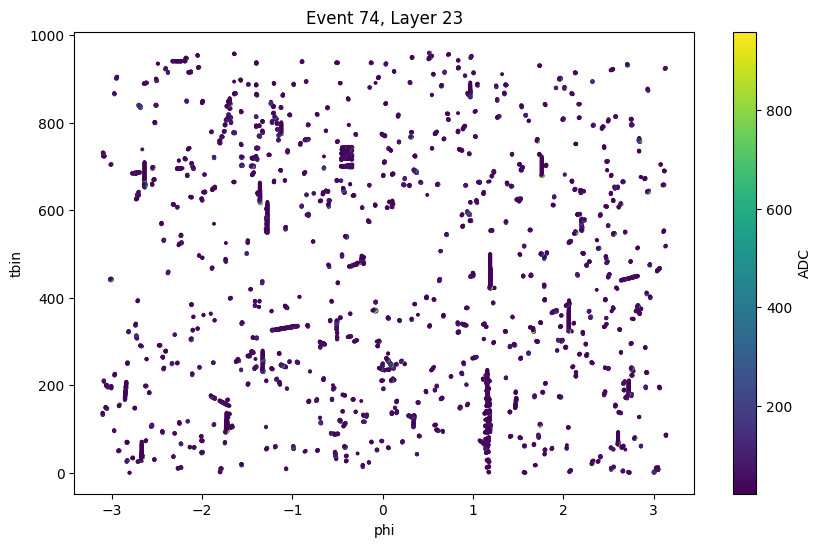

In [7]:
# build 2D network
phi_unique = np.sort(layer_df['phi'].unique())
phi_to_idx = {p: i for i, p in enumerate(phi_unique)}
tbin_min = int(layer_df['tbin'].min())
n_phi = len(phi_unique)
n_tbin = int(layer_df['tbin'].max()) - tbin_min + 1

grid = np.zeros((n_phi, n_tbin))
for _, row in layer_df.iterrows():
    grid[phi_to_idx[row['phi']], int(row['tbin']) - tbin_min] = row['adc']

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    layer_df['phi'],
    layer_df['tbin'],
    c=layer_df['adc'],
    cmap='viridis',
    s=8,
    linewidths=0,
)
fig.colorbar(scatter, ax=ax, label='ADC')
ax.set_xlabel('phi')
ax.set_ylabel('tbin')
ax.set_title(f'Event {EVENT}, Layer {LAYER}')
plt.show()


2989 local maxima found


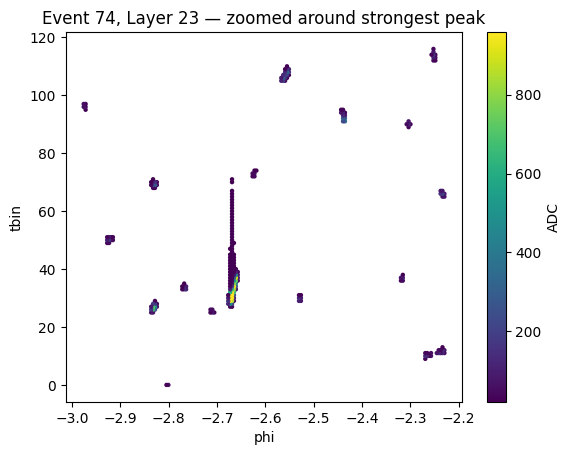

In [8]:
# zoom in and find local maximum
local_max = (maximum_filter(grid, size=3, mode='constant', cval=0) == grid) & (grid > 0)
peaks = np.argwhere(local_max)
print(f'{len(peaks)} local maxima found')

strongest = peaks[np.argmax(grid[peaks[:, 0], peaks[:, 1]])]
phi_center = float(phi_unique[strongest[0]])
tbin_center = int(strongest[1]) + tbin_min

zoom_hits = layer_df[
    (layer_df['phi'] > phi_center - 0.5) & (layer_df['phi'] < phi_center + 0.5) &
    (layer_df['tbin'] > tbin_center - 100) & (layer_df['tbin'] < tbin_center + 100)
]

fig, ax = plt.subplots()
scatter = ax.scatter(
    zoom_hits['phi'],
    zoom_hits['tbin'],
    c=zoom_hits['adc'],
    cmap='viridis',
    s=10,
    linewidths=0,
)
fig.colorbar(scatter, ax=ax, label='ADC')
ax.set_xlabel('phi')
ax.set_ylabel('tbin')
ax.set_title(f'Event {EVENT}, Layer {LAYER} — zoomed around strongest peak')
plt.show()


In [9]:
# 5x5 and 7x7 patch
results = {}
for PATCH in [5, 7]:
    half = PATCH // 2
    rows = []
    for pi, ti in peaks:
        patch = [
            grid[pi + dpi, ti + dti]
            if (0 <= pi + dpi < n_phi and 0 <= ti + dti < n_tbin) else 0.0
            for dpi in range(-half, half + 1)
            for dti in range(-half, half + 1)
        ]
        rows.append([EVENT, LAYER, float(phi_unique[pi]), int(ti + tbin_min)] + patch)
    cols = ['event', 'layer', 'phi', 'tbin'] + [f'p{k:02d}' for k in range(PATCH * PATCH)]
    results[PATCH] = pd.DataFrame(rows, columns=cols)


## Section B: Dataset Characterization

Compute basic descriptive features for the extracted 7×7 patches.
<!-- SECTION_B_DATASET_CHARACTERIZATION -->


In [10]:
# SECTION_B_DATASET_CHARACTERIZATION
px7 = [f'p{k:02d}' for k in range(49)]
patch_7x7_values = results[7][px7].values

dataset_characterization = results[7][['event', 'layer', 'phi', 'tbin']].copy()
dataset_characterization['max_ADC'] = patch_7x7_values.max(axis=1)
dataset_characterization['sum_ADC'] = patch_7x7_values.sum(axis=1)
dataset_characterization['nonzero_count'] = (patch_7x7_values > 0).sum(axis=1)
dataset_characterization['occupancy'] = dataset_characterization['nonzero_count'] / 49

display(dataset_characterization.head())
display(dataset_characterization[['max_ADC', 'sum_ADC', 'nonzero_count', 'occupancy']].describe().round(3))


,event,layer,phi,tbin,max_ADC,sum_ADC,nonzero_count,occupancy
0,74,23,-3.10146,132,141.0,683.0,8,0.163265
1,74,23,-3.10146,135,141.0,807.0,11,0.224490
2,74,23,-3.09856,731,277.0,934.0,9,0.183673
3,74,23,-3.09750,132,141.0,683.0,8,0.163265
4,74,23,-3.09750,135,141.0,807.0,11,0.224490


,max_ADC,sum_ADC,nonzero_count,occupancy
count,2989.000,2989.000,2989.000,2989.000
mean,215.340,1056.354,8.598,0.175
std,252.145,1823.602,4.567,0.093
min,21.000,21.000,1.000,0.020
25%,63.000,249.000,5.000,0.102
50%,117.000,461.000,8.000,0.163
75%,239.000,931.000,11.000,0.224
max,959.000,21348.000,40.000,0.816


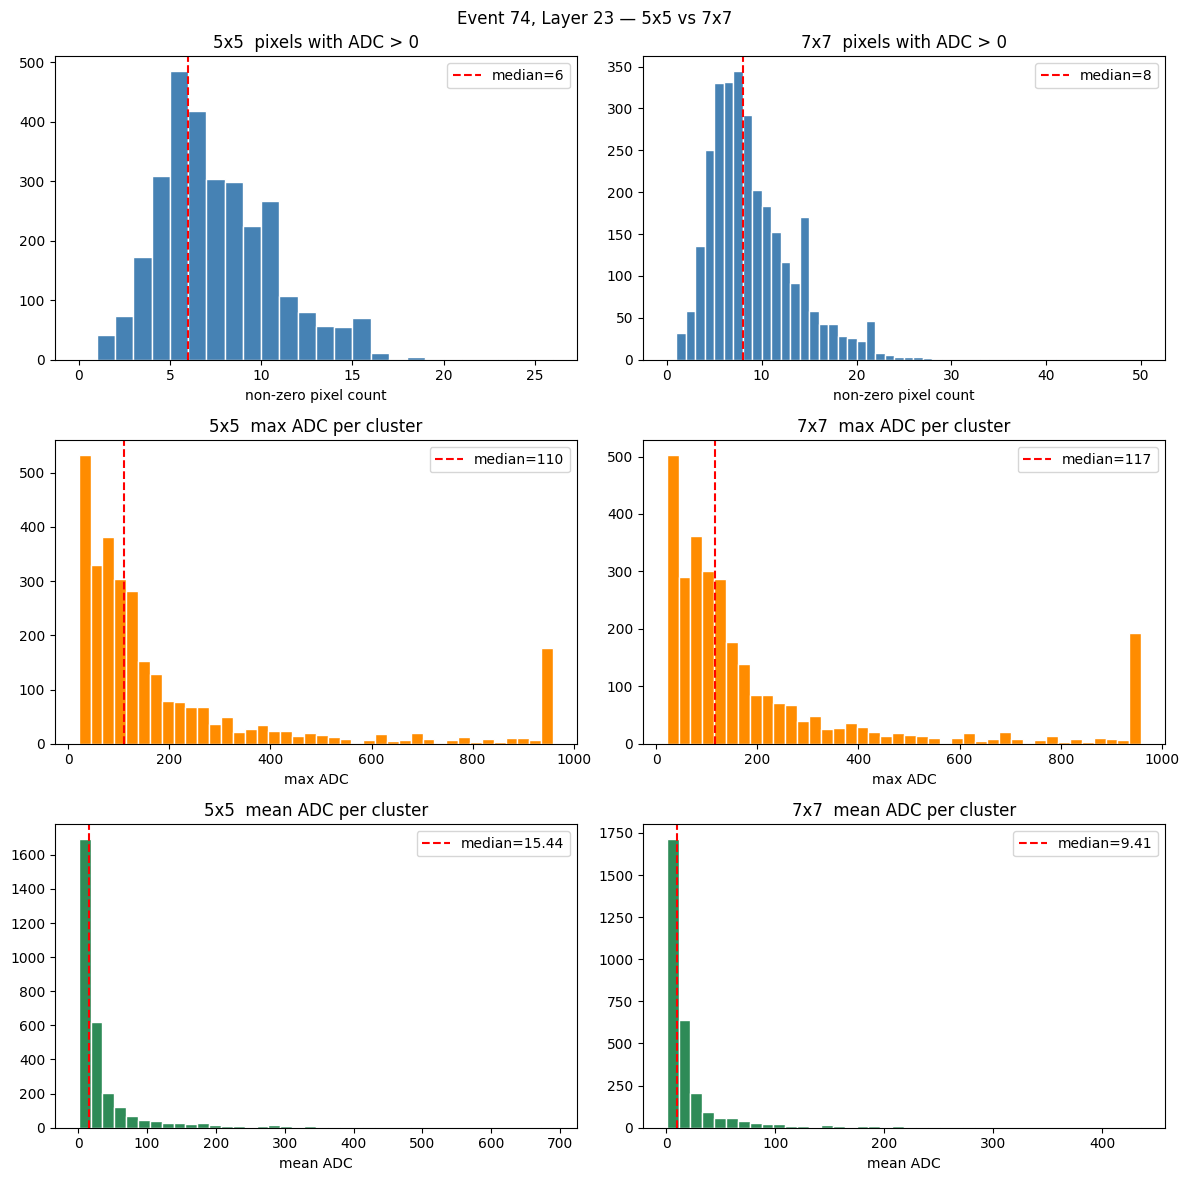

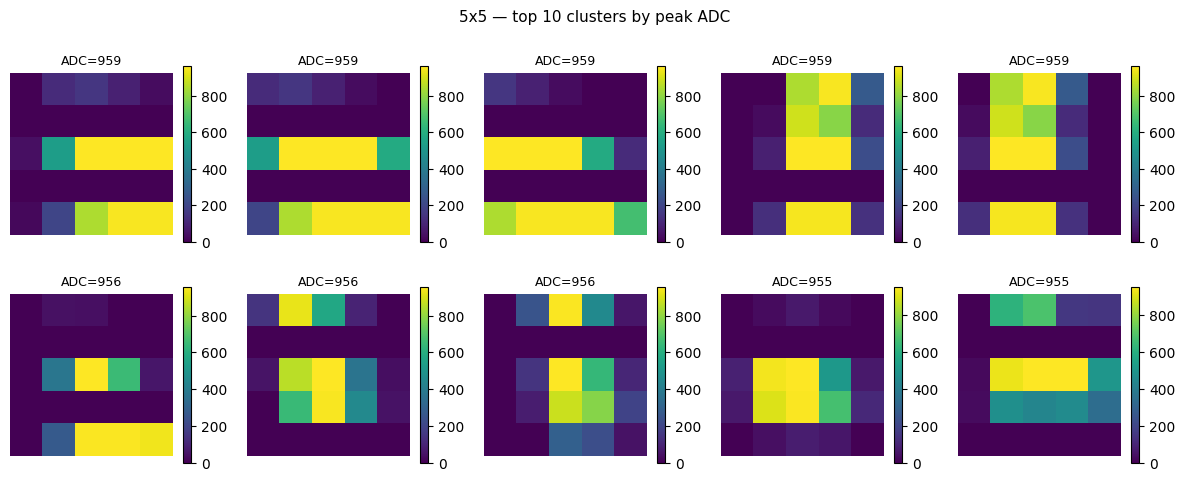

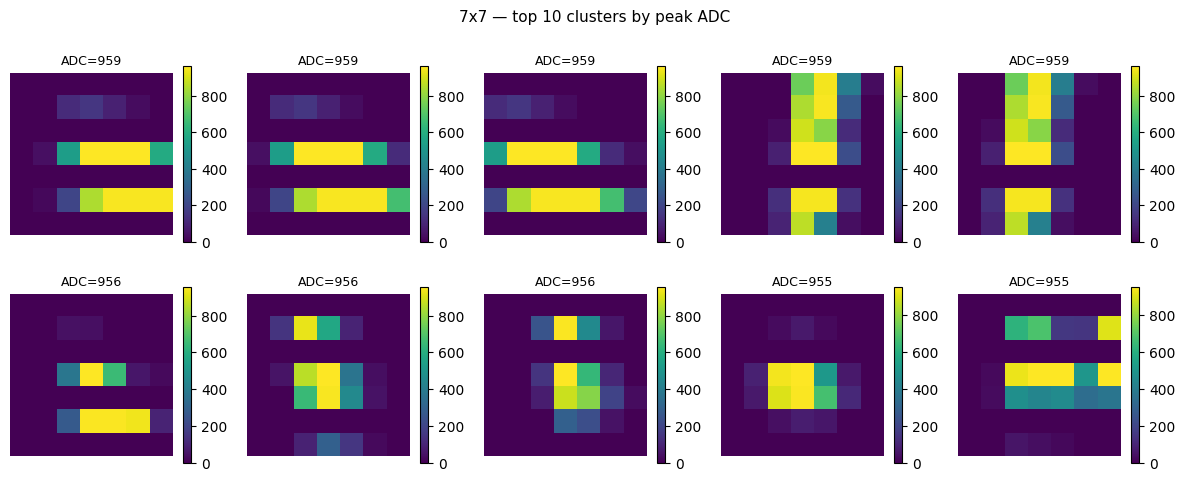

5x5 vs 7x7 charge retention
Retention = ADC_5x5 / ADC_7x7
Loss = 1 - Retention
Median retention: 0.987
Median loss: 0.013
% loss > 5%: 46.1%
% loss > 10%: 40.6%
Selected patch size for log transformation: 7x7


In [11]:
# display cluster patches + 5x5 vs 7x7 comparison
px_cols = {5: [f'p{k:02d}' for k in range(25)], 7: [f'p{k:02d}' for k in range(49)]}

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for col_i, PATCH in enumerate([5, 7]):
    vals = results[PATCH][px_cols[PATCH]].values
    n_nonzero = (vals > 0).sum(axis=1)
    adc_max = vals.max(axis=1)
    adc_mean = vals.mean(axis=1)

    # 直方图1：非零像素数
    axes[0, col_i].hist(n_nonzero, bins=range(0, PATCH * PATCH + 2), color='steelblue', edgecolor='white')
    axes[0, col_i].axvline(np.median(n_nonzero), color='red', linestyle='--', label=f'median={np.median(n_nonzero):.0f}')
    axes[0, col_i].set_title(f'{PATCH}x{PATCH}  pixels with ADC > 0')
    axes[0, col_i].set_xlabel('non-zero pixel count')
    axes[0, col_i].legend()

    # 直方图2：最大ADC
    axes[1, col_i].hist(adc_max, bins=40, color='darkorange', edgecolor='white')
    axes[1, col_i].axvline(np.median(adc_max), color='red', linestyle='--', label=f'median={np.median(adc_max):.0f}')
    axes[1, col_i].set_title(f'{PATCH}x{PATCH}  max ADC per cluster')
    axes[1, col_i].set_xlabel('max ADC')
    axes[1, col_i].legend()

    # 直方图3：平均ADC
    axes[2, col_i].hist(adc_mean, bins=40, color='seagreen', edgecolor='white')
    axes[2, col_i].axvline(np.median(adc_mean), color='red', linestyle='--', label=f'median={np.median(adc_mean):.2f}')
    axes[2, col_i].set_title(f'{PATCH}x{PATCH}  mean ADC per cluster')
    axes[2, col_i].set_xlabel('mean ADC')
    axes[2, col_i].legend()

plt.suptitle(f'Event {EVENT}, Layer {LAYER} — 5x5 vs 7x7', fontsize=12)
plt.tight_layout()
plt.show()

# top 10 cluster patches 目视检查
for PATCH in [5, 7]:
    center = (PATCH * PATCH) // 2
    top10 = results[PATCH].nlargest(10, f'p{center:02d}')
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.patch.set_facecolor('white')
    
    for i, (_, r) in enumerate(top10.iterrows()):
        patch_img = r[px_cols[PATCH]].to_numpy(dtype=float).reshape(PATCH, PATCH)
        ax = axes[i // 5, i % 5]
        im = ax.imshow(patch_img, cmap='viridis', aspect='equal',
                       interpolation='nearest')
        fig.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'ADC={r[f"p{center:02d}"]:.0f}', fontsize=9)
        ax.axis('off')
    
    plt.suptitle(f'{PATCH}x{PATCH} — top 10 clusters by peak ADC', fontsize=11)
    plt.tight_layout()
    plt.show()

# simple 5x5 vs 7x7 charge retention check
px5 = [f'p{k:02d}' for k in range(25)]
px7 = [f'p{k:02d}' for k in range(49)]
adc_5x5 = results[5][px5].sum(axis=1).astype(float)
adc_7x7 = results[7][px7].sum(axis=1).astype(float)
retention = np.where(adc_7x7 > 0, adc_5x5 / adc_7x7, np.nan)
loss = 1 - retention

print('5x5 vs 7x7 charge retention')
print('Retention = ADC_5x5 / ADC_7x7')
print('Loss = 1 - Retention')
print(f'Median retention: {np.nanmedian(retention):.3f}')
print(f'Median loss: {np.nanmedian(loss):.3f}')
print(f'% loss > 5%: {100 * np.nanmean(loss > 0.05):.1f}%')
print(f'% loss > 10%: {100 * np.nanmean(loss > 0.10):.1f}%')

# choose patch size for downstream log transformation
SELECTED_PATCH_SIZE = 7
print(f'Selected patch size for log transformation: {SELECTED_PATCH_SIZE}x{SELECTED_PATCH_SIZE}')


## Log Transformation for Selected Patch Size

After comparing 5×5 and 7×7 patches, apply `log1p(ADC)` only to the selected patch dataset and save the raw/log1p outputs.


In [ ]:
# Log transformation and save selected patch dataset
# Run this after comparing 5x5 vs 7x7 and choosing SELECTED_PATCH_SIZE.
PATCH = SELECTED_PATCH_SIZE
px_cols = [f'p{k:02d}' for k in range(PATCH * PATCH)]

selected_raw = results[PATCH].copy()
raw_vals = selected_raw[px_cols].values.astype(float)
log_vals = np.log1p(raw_vals)

selected_log = selected_raw.copy()
selected_log[px_cols] = log_vals

raw_path = f"/Users/amandadongsmacbookpro/Desktop/Gunther Research/Research/output/clusters_ev{EVENT}_l{LAYER}_{PATCH}x{PATCH}_raw.csv"
log_path = f"/Users/amandadongsmacbookpro/Desktop/Gunther Research/Research/output/clusters_ev{EVENT}_l{LAYER}_{PATCH}x{PATCH}_log1p.csv"

selected_raw.to_csv(raw_path, index=False)
selected_log.to_csv(log_path, index=False)

print(f'Selected patch size: {PATCH}x{PATCH}')
print(f'raw ADC range:   [{raw_vals.min():.1f}, {raw_vals.max():.1f}]')
print(f'log1p ADC range: [{log_vals.min():.3f}, {log_vals.max():.3f}]')
print(f'saved raw selected patches: {raw_path}')
print(f'saved log1p selected patches: {log_path}')


## Cluster filtering for valid ripple-shaped patches

This section filters extracted cluster patches using three quality parameters:

- `ADC_THRESHOLD`: the cluster peak ADC must be greater than this value.
- `MIN_NONZERO_PIXELS`: the patch must contain at least this many pixels with ADC > 0.
- `MAX_EDGE_ADC_FRACTION`: if too much charge is on the patch edge, the cluster may be cut off by the patch window and is removed.

It also checks a simple ripple-shape rule: moving from the center outward, ADC values are allowed to stay equal or decrease, but not increase. In code, this is checked ring by ring around the center pixel.


In [13]:
# Cluster filtering parameters
# You can tune these numbers and rerun this cell.
ADC_THRESHOLD = 80
MIN_NONZERO_PIXELS = 3
MAX_EDGE_ADC_FRACTION = 0.30
FILTER_PATCH_SIZE = SELECTED_PATCH_SIZE  # can be changed to 5, 7, 9, ...


def get_patch_from_grid(grid, center_i, center_j, patch_size):
    """Return a square patch centered at (center_i, center_j).

    Pixels outside the original grid are filled with 0.
    """
    if patch_size % 2 == 0:
        raise ValueError('patch_size must be odd, for example 5, 7, or 9.')

    half = patch_size // 2
    patch = np.zeros((patch_size, patch_size), dtype=float)

    for di in range(-half, half + 1):
        for dj in range(-half, half + 1):
            gi = center_i + di
            gj = center_j + dj
            if 0 <= gi < grid.shape[0] and 0 <= gj < grid.shape[1]:
                patch[di + half, dj + half] = grid[gi, gj]

    return patch


def edge_adc_fraction(patch):
    """Return the fraction of total ADC located on the outer edge of a patch."""
    total_adc = patch.sum()
    if total_adc <= 0:
        return 1.0

    edge_mask = np.zeros(patch.shape, dtype=bool)
    edge_mask[0, :] = True
    edge_mask[-1, :] = True
    edge_mask[:, 0] = True
    edge_mask[:, -1] = True

    return patch[edge_mask].sum() / total_adc


def is_ripple_shaped(patch):
    """Check whether ADC decreases from the center outward, ring by ring.

    Ring 0 is the center pixel. Ring 1 is the 8 neighboring pixels.
    Ring 2 is the next square ring, and so on.

    The rule used here is: max(outer ring) <= min(inner ring).
    This is a strict quality cut, because any brighter pixel farther from the center
    means the patch is not cleanly decreasing outward. Equal values are allowed.
    """
    if patch.shape[0] != patch.shape[1] or patch.shape[0] % 2 == 0:
        raise ValueError('patch must be square with an odd size.')

    size = patch.shape[0]
    center = size // 2

    yy, xx = np.indices(patch.shape)
    ring_distance = np.maximum(np.abs(yy - center), np.abs(xx - center))

    for ring in range(1, center + 1):
        inner_values = patch[ring_distance == ring - 1]
        outer_values = patch[ring_distance == ring]
        if outer_values.max() > inner_values.min():
            return False

    return True


def filter_clusters(
    grid,
    peaks,
    phi_unique,
    tbin_min,
    event,
    layer,
    patch_size=7,
    adc_threshold=ADC_THRESHOLD,
    min_nonzero_pixels=MIN_NONZERO_PIXELS,
    max_edge_adc_fraction=MAX_EDGE_ADC_FRACTION,
):
    """Filter cluster candidates and create a filtered copy of the original 2D grid.

    Returns
    -------
    filtered_clusters : pandas.DataFrame
        One row per valid cluster, including metadata, quality metrics, and patch pixels.
    filtered_grid : numpy.ndarray
        A copy-shaped grid where only pixels belonging to valid cluster patches are kept.
    rejected_clusters : pandas.DataFrame
        One row per rejected cluster, with the reason it failed.
    """
    if patch_size % 2 == 0:
        raise ValueError('patch_size must be odd, for example 5, 7, or 9.')

    half = patch_size // 2
    pixel_cols = [f'p{k:02d}' for k in range(patch_size * patch_size)]
    kept_rows = []
    rejected_rows = []
    filtered_grid = np.zeros_like(grid, dtype=float)

    for peak_i, peak_j in peaks:
        patch = get_patch_from_grid(grid, peak_i, peak_j, patch_size)

        peak_adc = float(patch.max())
        center_adc = float(patch[half, half])
        nonzero_pixels = int((patch > 0).sum())
        edge_fraction = float(edge_adc_fraction(patch))
        ripple_ok = is_ripple_shaped(patch)

        fail_reasons = []
        if peak_adc <= adc_threshold:
            fail_reasons.append('peak_adc_below_threshold')
        if nonzero_pixels < min_nonzero_pixels:
            fail_reasons.append('too_few_nonzero_pixels')
        if edge_fraction > max_edge_adc_fraction:
            fail_reasons.append('too_much_adc_on_edge')
        if not ripple_ok:
            fail_reasons.append('not_ripple_shaped')

        base_info = [
            event,
            layer,
            float(phi_unique[peak_i]),
            int(peak_j + tbin_min),
            peak_adc,
            center_adc,
            nonzero_pixels,
            edge_fraction,
            ripple_ok,
        ]

        if fail_reasons:
            rejected_rows.append(base_info + [';'.join(fail_reasons)] + patch.reshape(-1).tolist())
            continue

        kept_rows.append(base_info + patch.reshape(-1).tolist())

        # Copy the accepted patch back into a grid with the same shape as the original.
        # If accepted patches overlap, keep the larger ADC value at each pixel.
        for di in range(-half, half + 1):
            for dj in range(-half, half + 1):
                gi = peak_i + di
                gj = peak_j + dj
                if 0 <= gi < grid.shape[0] and 0 <= gj < grid.shape[1]:
                    filtered_grid[gi, gj] = max(filtered_grid[gi, gj], patch[di + half, dj + half])

    info_cols = [
        'event',
        'layer',
        'phi',
        'tbin',
        'peak_adc',
        'center_adc',
        'nonzero_pixels',
        'edge_adc_fraction',
        'ripple_shaped',
    ]

    filtered_clusters = pd.DataFrame(kept_rows, columns=info_cols + pixel_cols)
    rejected_clusters = pd.DataFrame(rejected_rows, columns=info_cols + ['reject_reason'] + pixel_cols)

    return filtered_clusters, filtered_grid, rejected_clusters


Filter patch size: 7x7
Original candidate clusters: 2989
Valid clusters after filtering: 46
Rejected clusters: 2943
Top reject reasons:
reject_reason
not_ripple_shaped                                                                         1656
peak_adc_below_threshold;not_ripple_shaped                                                 742
too_much_adc_on_edge;not_ripple_shaped                                                     302
peak_adc_below_threshold;too_much_adc_on_edge;not_ripple_shaped                            122
peak_adc_below_threshold;too_few_nonzero_pixels                                             53
peak_adc_below_threshold                                                                    31
peak_adc_below_threshold;too_few_nonzero_pixels;not_ripple_shaped                           29
peak_adc_below_threshold;too_few_nonzero_pixels;too_much_adc_on_edge;not_ripple_shaped       6
too_few_nonzero_pixels                                                                    

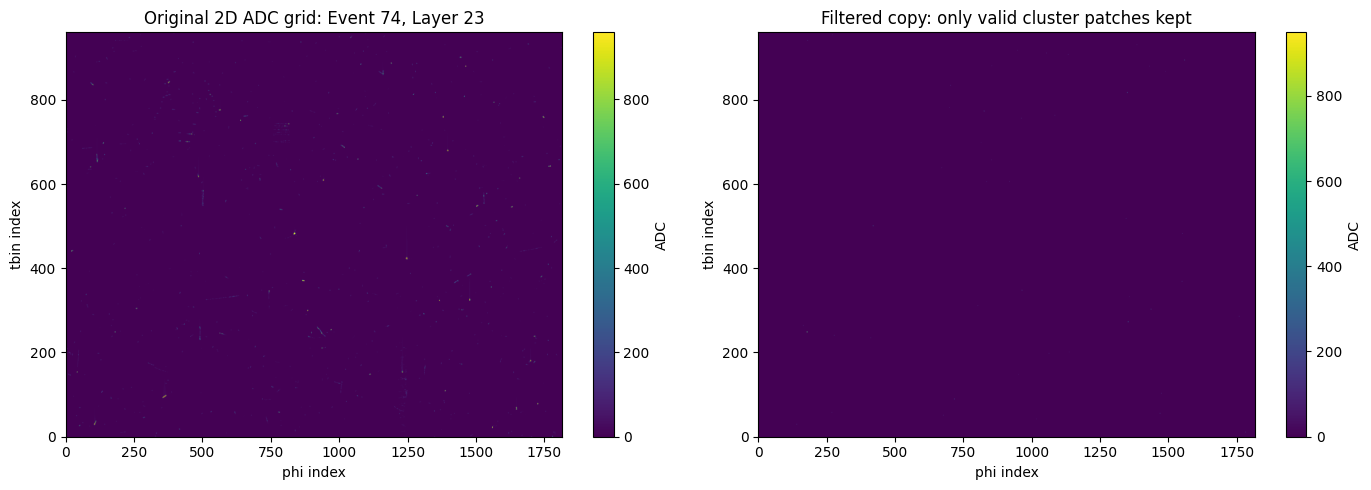

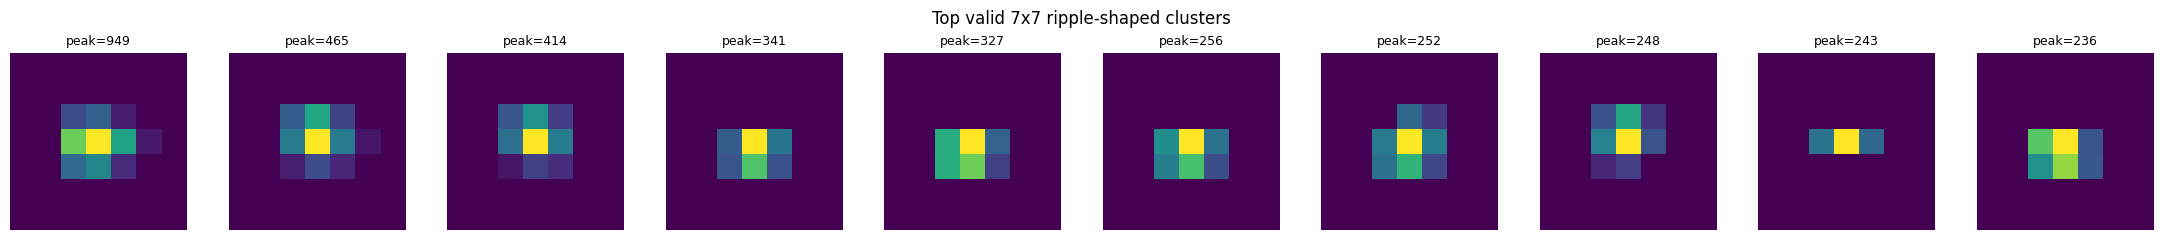

In [14]:
# Run the filter and visualize the filtered 2D image copy
filtered_clusters, filtered_grid, rejected_clusters = filter_clusters(
    grid=grid,
    peaks=peaks,
    phi_unique=phi_unique,
    tbin_min=tbin_min,
    event=EVENT,
    layer=LAYER,
    patch_size=FILTER_PATCH_SIZE,
    adc_threshold=ADC_THRESHOLD,
    min_nonzero_pixels=MIN_NONZERO_PIXELS,
    max_edge_adc_fraction=MAX_EDGE_ADC_FRACTION,
)

print(f'Filter patch size: {FILTER_PATCH_SIZE}x{FILTER_PATCH_SIZE}')
print(f'Original candidate clusters: {len(peaks)}')
print(f'Valid clusters after filtering: {len(filtered_clusters)}')
print(f'Rejected clusters: {len(rejected_clusters)}')

if len(rejected_clusters) > 0:
    print('Top reject reasons:')
    print(rejected_clusters['reject_reason'].value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(grid.T, origin='lower', aspect='auto', cmap='viridis')
axes[0].set_title(f'Original 2D ADC grid: Event {EVENT}, Layer {LAYER}')
axes[0].set_xlabel('phi index')
axes[0].set_ylabel('tbin index')
fig.colorbar(im0, ax=axes[0], label='ADC')

im1 = axes[1].imshow(filtered_grid.T, origin='lower', aspect='auto', cmap='viridis')
axes[1].set_title('Filtered copy: only valid cluster patches kept')
axes[1].set_xlabel('phi index')
axes[1].set_ylabel('tbin index')
fig.colorbar(im1, ax=axes[1], label='ADC')

plt.tight_layout()
plt.show()

# Optional: inspect the strongest valid ripple-shaped clusters
if len(filtered_clusters) > 0:
    pixel_cols = [f'p{k:02d}' for k in range(FILTER_PATCH_SIZE * FILTER_PATCH_SIZE)]
    top_n = min(10, len(filtered_clusters))
    top_clusters = filtered_clusters.nlargest(top_n, 'peak_adc')

    fig, axes = plt.subplots(1, top_n, figsize=(2.2 * top_n, 2.4))
    if top_n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, top_clusters.iterrows()):
        patch_img = row[pixel_cols].to_numpy(dtype=float).reshape(FILTER_PATCH_SIZE, FILTER_PATCH_SIZE)
        im = ax.imshow(patch_img, cmap='viridis', interpolation='nearest')
        ax.set_title(f'peak={row["peak_adc"]:.0f}', fontsize=9)
        ax.axis('off')

    plt.suptitle(f'Top valid {FILTER_PATCH_SIZE}x{FILTER_PATCH_SIZE} ripple-shaped clusters')
    plt.tight_layout()
    plt.show()
